# Project: A/B Testing & Statistical Analysis

This notebook applies statistical hypothesis testing to validate A/B test results.  
We will:
- Explore the dataset
- Perform hypothesis tests (t-test, chi-square)
- Calculate confidence intervals
- Measure effect size
- Provide business recommendations
- Optionally, segment customers with clustering


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [8]:
### load dataset

df = pd.read_csv("ab_data.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


## Data Exploration
We check:
- Sample sizes per group
- Overall conversion rate
- Balance between groups
- convertion rate difference between control and treatment


Group counts:
 group
treatment    147276
control      147202
Name: count, dtype: int64
Overall conversion rate: 0.11965919355605512


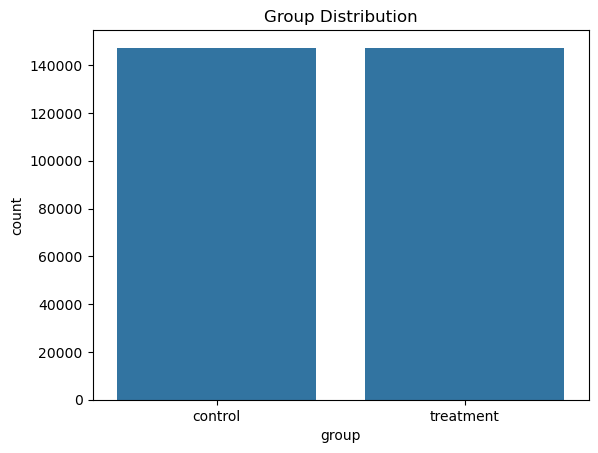

group
control      0.120399
treatment    0.118920
Name: converted, dtype: float64


In [11]:
# Check sample sizes
print("Group counts:\n", df['group'].value_counts())

# Overall conversion rate
print("Overall conversion rate:", df['converted'].mean())

# Visualize group distribution
sns.countplot(x='group', data=df)
plt.title("Group Distribution")
plt.show()

# Conversion rate by group
print(df.groupby('group')['converted'].mean())


## Hypothesis Testing
we test:
conversion difference(chi-square)

We use the **Chi-Square test** to check if conversion rates differ significantly between groups.  
If p-value < 0.05 → statistically significant difference.


In [14]:
## chi-square test for convertion

contingency_table = pd.crosstab(df['group'], df['converted'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square: {chi2:.4f}, P-value: {p_value:.4f}")
                                    

Chi-square: 1.5160, P-value: 0.2182


## Phase 4: Confidence Intervals
We calculate 95% confidence intervals for conversion rates in each group.


In [15]:
# Conversion rates by group
control_conv = df[df['group'] == 'control']['converted']
treatment_conv = df[df['group'] == 'treatment']['converted']
mean_control = control_conv.mean()
mean_treatment = treatment_conv.mean()

# standard error
se_control = np.sqrt(mean_control*(1-mean_control)/len(control_conv))
se_treatment = np.sqrt(mean_treatment*(1-mean_treatment)/len(treatment_conv))

# 95% CI
ci_control = (mean_control - 1.96*se_control, mean_control + 1.96*se_control)
ci_treatment = (mean_treatment - 1.96*se_treatment, mean_treatment + 1.96*se_treatment)

print(f"95% CI for control conversion : {ci_control}")
print(f"95% CI for treatment conversion : {ci_treatment}")

95% CI for control conversion : (np.float64(0.11873670945344914), np.float64(0.12206164926450308))
95% CI for treatment conversion : (np.float64(0.11726638282966392), np.float64(0.12057277630013319))


## Phase 5: Effect Size
We calculate Cohen’s h to measure practical significance of the difference in proportions.
- Small ~0.2  
- Medium ~0.5  
- Large ~0.8  



In [16]:
# cohen's h for proportions
def cohens_h(p1,p2):
    return 2*(np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))
cohens_h_value = cohens_h(mean_treatment, mean_control)
print(f"Cohen's h: {cohens_h_value:.4f}")

Cohen's h: -0.0046


## Phase 6: Business Insights
We compare conversion rates and provide a recommendation:
- If treatment is higher and statistically significant → rollout new page.
- Otherwise → keep control page.


In [17]:
print(f"Control Conversion Rate : {mean_control:.2%}")
print(f"Treatment Conversion Rate : {mean_treatment:.2%}")

if mean_treatment > mean_control and p_value < 0.05:
    print("Treatment group performs significantly better. Recommend rollout.")
else:
     print("No significant improvement. Stick with Control.")

Control Conversion Rate : 12.04%
Treatment Conversion Rate : 11.89%
No significant improvement. Stick with Control.
